# 🌲 Forest Cover Type Classification

**Author:** Mohamed ElAmine Haj Mohamed 
**Date:** September 2026  
**Dataset:** UCI Covertype Dataset (Blackthorn Forest, Colorado)  

## Goal
Predict the predominant forest cover type from cartographic features (elevation, slope, soil, wilderness area, etc.) using supervised machine learning. The dataset contains 581,012 samples with 54 features, and the task is a 7-class classification problem.

---
## Section 0 — Imports & Configuration

In [1]:
import importlib
import subprocess
import sys

REQUIRED_LIBRARIES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "xgboost": "xgboost",
    "joblib": "joblib",
    "gradio": "gradio",
}

missing = []

for import_name, install_name in REQUIRED_LIBRARIES.items():
    try:
        importlib.import_module(import_name)
        print(f"  ✅  {install_name}")
    except ImportError:
        print(f"  ❌  {install_name}  ← missing")
        missing.append(install_name)

if missing:
    print(f"\n Installing {len(missing)} missing package(s): {', '.join(missing)} …")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    print("\n✅  All packages installed. Re-run this cell to confirm.")
else:
    print("\n✅  All required libraries are already installed.")

  ✅  pandas
  ✅  numpy
  ✅  matplotlib
  ✅  seaborn
  ✅  scikit-learn
  ✅  xgboost
  ✅  joblib
  ✅  gradio

✅  All required libraries are already installed.


In [2]:
# --- Core data libraries
import pandas as pd
import numpy as np

# --- Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, cohen_kappa_score
)
from sklearn.utils.class_weight import compute_class_weight

# --- XGBoost
from xgboost import XGBClassifier

# --- Model persistence
import joblib

# --- Gradio
import gradio as gr

# --- Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

import warnings
warnings.filterwarnings("ignore")

# --- Cover type names mapping
COVER_TYPE_NAMES = {
    1: 'Spruce/Fir',
    2: 'Lodgepole Pine',
    3: 'Ponderosa Pine',
    4: 'Cottonwood/Willow',
    5: 'Aspen',
    6: 'Douglas Fir',
    7: 'Krummholz'
}

# --- Feature lists
CONTINUOUS_FEATURES = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon',
    'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points'
]

WILDERNESS_FEATURES = [
    'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4'
]

SOIL_FEATURES = [f'Soil_Type{i}' for i in range(1, 41)]

print("All imports successful.")
print(f"Continuous features : {len(CONTINUOUS_FEATURES)}")
print(f"Wilderness features: {len(WILDERNESS_FEATURES)}")
print(f"Soil features      : {len(SOIL_FEATURES)}")
print(f"Total features     : {len(CONTINUOUS_FEATURES) + len(WILDERNESS_FEATURES) + len(SOIL_FEATURES)}")

All imports successful.
Continuous features : 10
Wilderness features: 4
Soil features      : 40
Total features     : 54


---
## Section 1 — Data Loading

The UCI Covertype dataset is distributed as a raw `.data` file with **no header row**. Each row is comma-separated with 55 columns: 10 continuous features, 4 wilderness area indicators, 40 soil type indicators, and the target `Cover_Type` (1–7). We load it directly using `pd.read_csv` with `header=None` and assign column names manually.

In [3]:
# --- Column names (54 features + 1 target)
COLUMN_NAMES = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon',
    'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points',
    'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
    'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
    'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
    'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15',
    'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20',
    'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25',
    'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
    'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35',
    'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40',
    'Cover_Type'
]

print(f"Total columns defined: {len(COLUMN_NAMES)}")

Total columns defined: 55


In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mohamedaminehm/covtype/covtype.data


In [ ]:
# --- Load the dataset (local covtype.data preferred, Kaggle path as fallback)
data_path = os.path.join(os.getcwd(), 'covtype.data')
if not os.path.exists(data_path):
    data_path = "/kaggle/input/datasets/mohamedaminehm/covtype/covtype.data"
    print("Local covtype.data not found - falling back to Kaggle input path.")

df = pd.read_csv(data_path, header=None, names=COLUMN_NAMES)

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")
print(f"\nFirst 5 rows:")
df.head()

In [6]:
# --- Data types and memory usage
print("Column data types:")
print(df.dtypes.value_counts())
print(f"\nTotal memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nTarget value range: {df['Cover_Type'].min()} to {df['Cover_Type'].max()}")
print(f"Unique target classes: {df['Cover_Type'].nunique()}")

Column data types:
int64    55
Name: count, dtype: int64

Total memory: 255.6 MB

Target value range: 1 to 7
Unique target classes: 7


---
## Section 2 — Exploratory Data Analysis (EDA)

### 2.1 Basic Statistics — Continuous Features

We examine summary statistics for the 10 continuous features to understand distributions, ranges, and potential outliers. The binary features (wilderness and soil indicators) are all 0/1 by design.

In [7]:
# --- Summary statistics for continuous features
df[CONTINUOUS_FEATURES].describe().round(2)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
count,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00
mean,2959.37,155.66,14.10,269.43,46.42,2350.15,212.15,223.32,142.53,1980.29
std,279.98,111.91,7.49,212.55,58.30,1559.25,26.77,19.77,38.27,1324.20
min,1859.00,0.00,0.00,0.00,-173.00,0.00,0.00,0.00,0.00,0.00
25%,2809.00,58.00,9.00,108.00,7.00,1106.00,198.00,213.00,119.00,1024.00
50%,2996.00,127.00,13.00,218.00,30.00,1997.00,218.00,226.00,143.00,1710.00
75%,3163.00,260.00,18.00,384.00,69.00,3328.00,231.00,237.00,168.00,2550.00
max,3858.00,360.00,66.00,1397.00,601.00,7117.00,254.00,254.00,254.00,7173.00


### 2.2 Target Distribution

The cover type labels are unevenly distributed — some classes are much more frequent than others. Understanding this class imbalance is important because it affects model training and evaluation choices.

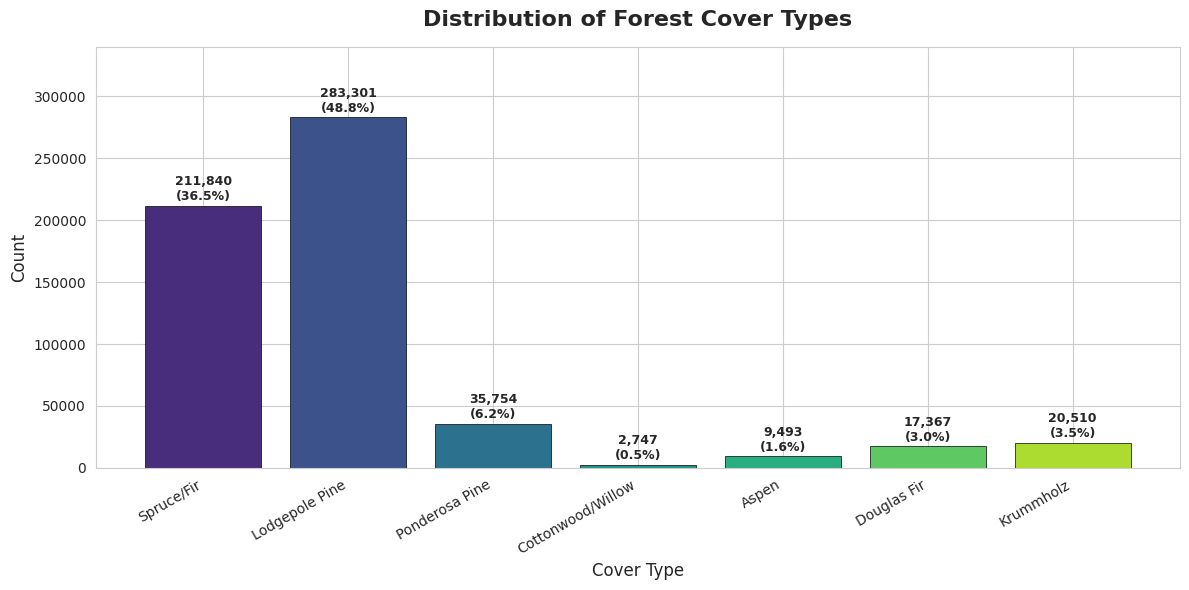


Most common class: Lodgepole Pine (283,301 samples)
Least common class: Cottonwood/Willow (2,747 samples)
Imbalance ratio (max/min): 103.1x


In [8]:
# --- Target distribution bar chart
target_counts = df['Cover_Type'].value_counts().sort_index()
target_pcts = df['Cover_Type'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    [COVER_TYPE_NAMES[k] for k in target_counts.index],
    target_counts.values,
    color=sns.color_palette("viridis", 7),
    edgecolor='black', linewidth=0.5
)

# Add count and percentage labels on each bar
for bar, count, pct in zip(bars, target_counts.values, target_pcts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2000,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title('Distribution of Forest Cover Types', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Cover Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_ylim(0, target_counts.max() * 1.2)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nMost common class: {COVER_TYPE_NAMES[target_counts.idxmax()]} ({target_counts.max():,} samples)")
print(f"Least common class: {COVER_TYPE_NAMES[target_counts.idxmin()]} ({target_counts.min():,} samples)")
print(f"Imbalance ratio (max/min): {target_counts.max() / target_counts.min():.1f}x")

> **Note on Class Imbalance:** The dataset is heavily imbalanced. Lodgepole Pine (class 2) accounts for ~49% of all samples, while Cottonwood/Willow (class 4) represents only ~0.5%. This 100:1 imbalance ratio means models may be biased toward the majority classes. We'll address this with `class_weight='balanced'` in the models and evaluate using Macro F1 (which treats all classes equally).

### 2.3 Feature Distributions

Understanding the distribution of each continuous feature helps identify scaling needs, skewness, and potential relationships with the target.

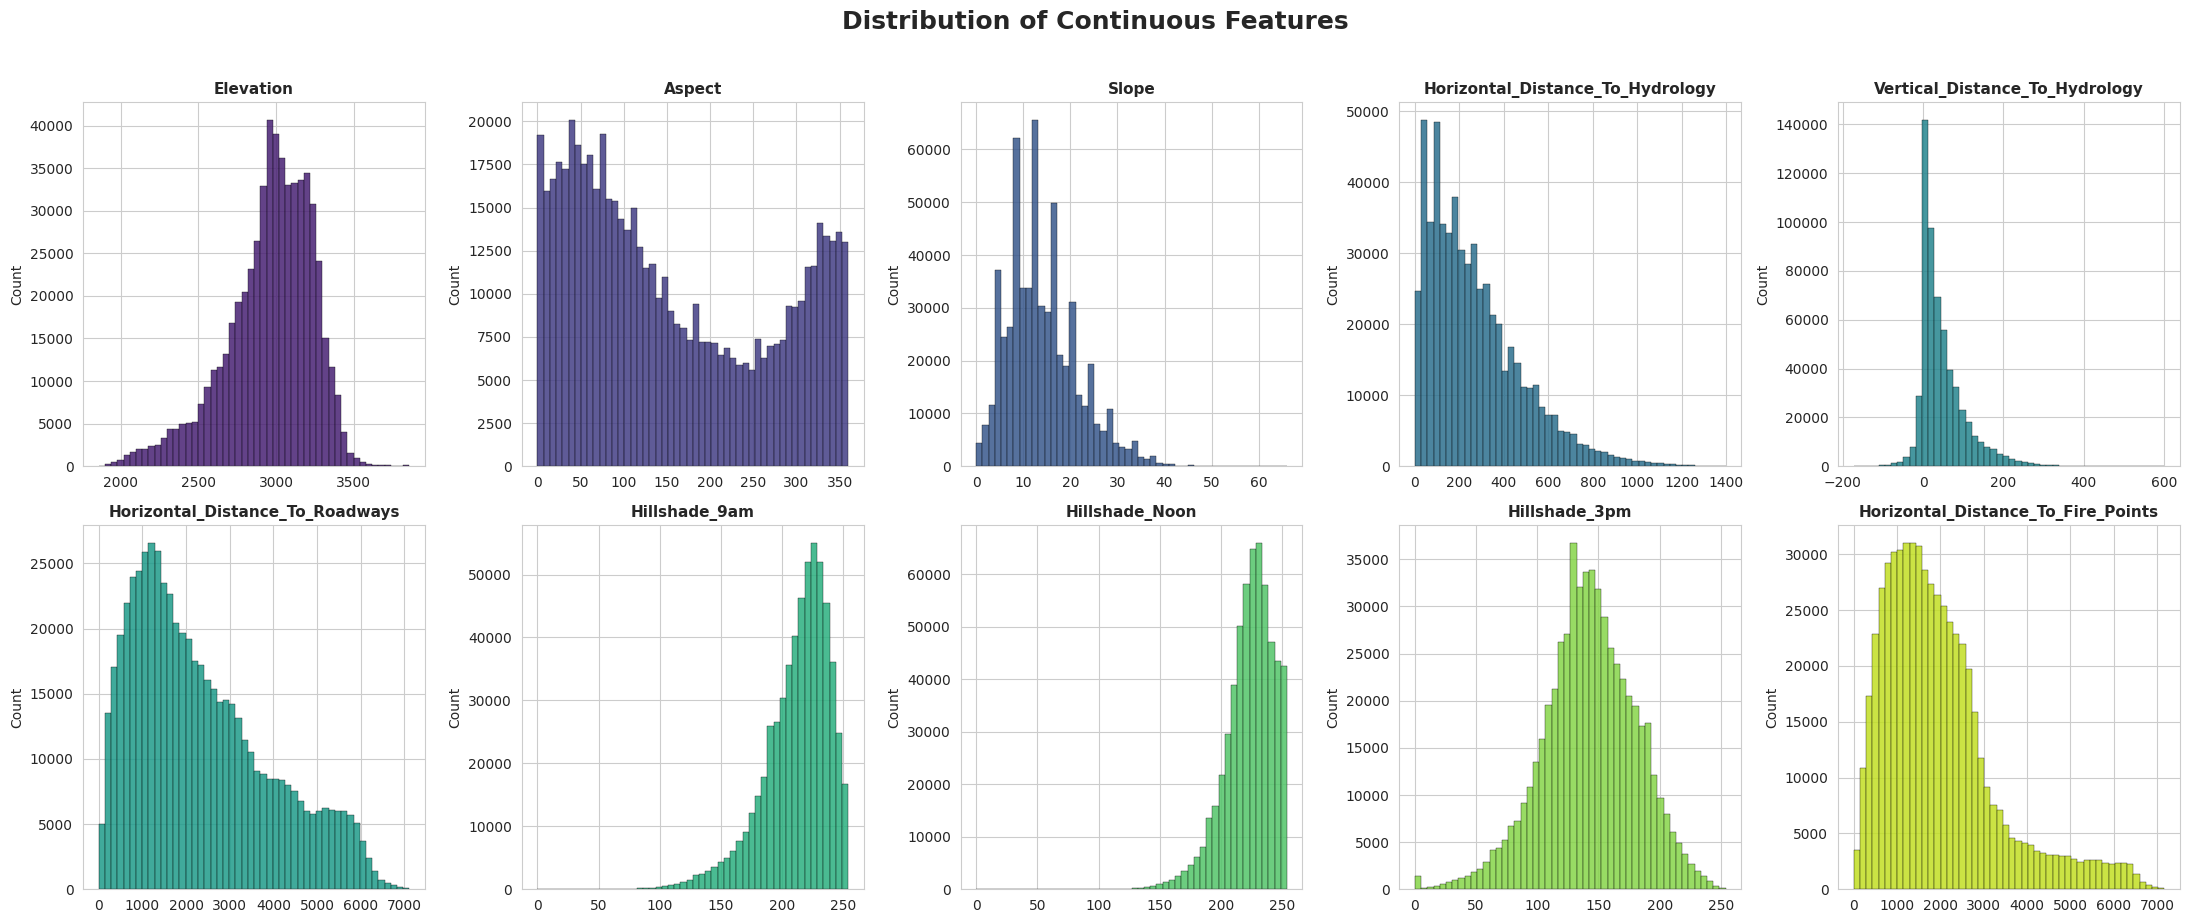

In [9]:
# --- Histograms for all 10 continuous features
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.ravel()

for i, feat in enumerate(CONTINUOUS_FEATURES):
    axes[i].hist(df[feat], bins=50, color=sns.color_palette("viridis", 10)[i],
                 edgecolor='black', linewidth=0.3, alpha=0.85)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

fig.suptitle('Distribution of Continuous Features', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

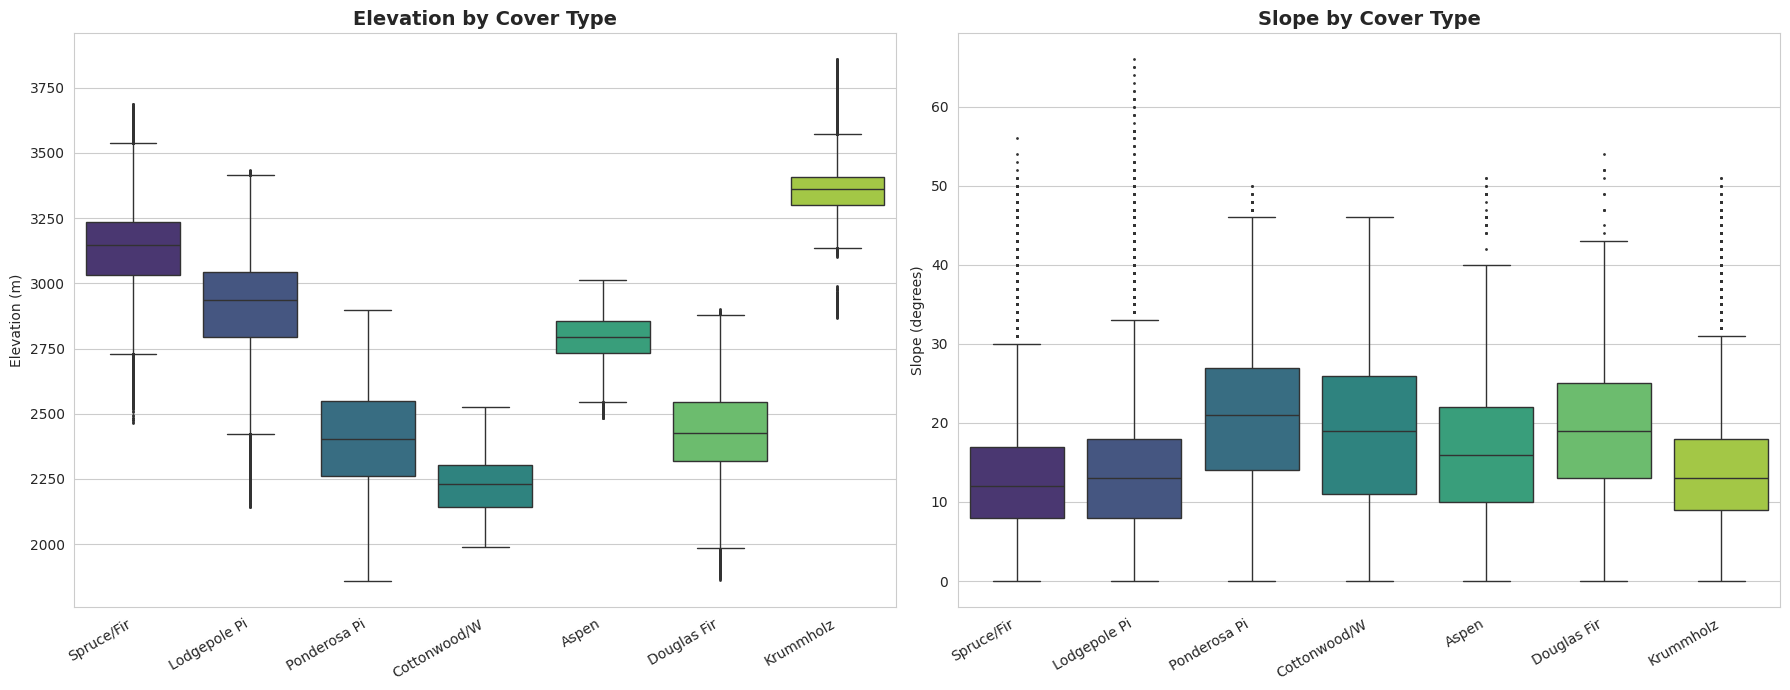

In [10]:
# --- Boxplots: Elevation and Slope by Cover Type
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

palette = sns.color_palette("viridis", 7)

sns.boxplot(
    data=df, x='Cover_Type', y='Elevation', palette=palette,
    ax=axes[0], fliersize=1
)
axes[0].set_xticklabels([COVER_TYPE_NAMES[i+1][:12] for i in range(7)], rotation=30, ha='right')
axes[0].set_title('Elevation by Cover Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Elevation (m)')

sns.boxplot(
    data=df, x='Cover_Type', y='Slope', palette=palette,
    ax=axes[1], fliersize=1
)
axes[1].set_xticklabels([COVER_TYPE_NAMES[i+1][:12] for i in range(7)], rotation=30, ha='right')
axes[1].set_title('Slope by Cover Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Slope (degrees)')

plt.tight_layout()
plt.show()

### 2.4 Correlation Heatmap

A correlation heatmap on the continuous features reveals which features are linearly related. Strong correlations may indicate redundancy, while weak correlations suggest independent information.

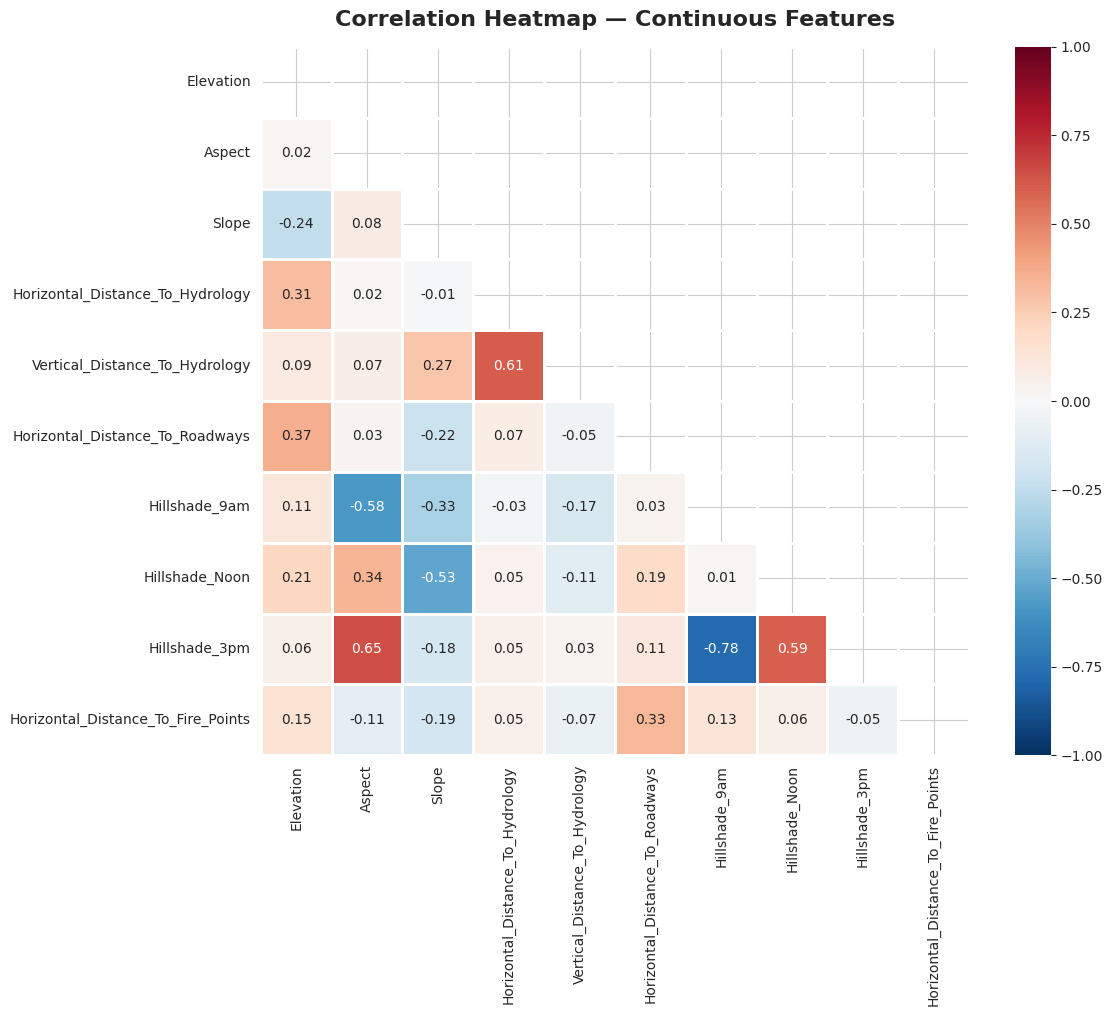


Top correlated feature pairs (absolute):
  Hillshade_9am                       <-> Hillshade_3pm                      : -0.780
  Aspect                              <-> Hillshade_3pm                      : +0.647
  Horizontal_Distance_To_Hydrology    <-> Vertical_Distance_To_Hydrology     : +0.606
  Hillshade_Noon                      <-> Hillshade_3pm                      : +0.594
  Aspect                              <-> Hillshade_9am                      : -0.579


In [11]:
# --- Correlation heatmap for continuous features
corr_matrix = df[CONTINUOUS_FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=1, ax=ax,
    annot_kws={'size': 10}
)

ax.set_title('Correlation Heatmap — Continuous Features', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Print top correlations
print("\nTop correlated feature pairs (absolute):")
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append((
            corr_matrix.columns[i],
            corr_matrix.columns[j],
            corr_matrix.iloc[i, j]
        ))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for f1, f2, val in corr_pairs[:5]:
    print(f"  {f1:35s} <-> {f2:35s}: {val:+.3f}")

### 2.5 Wilderness & Soil Overview

The wilderness and soil features are one-hot encoded. We examine sample counts per wilderness area and the most common soil types.

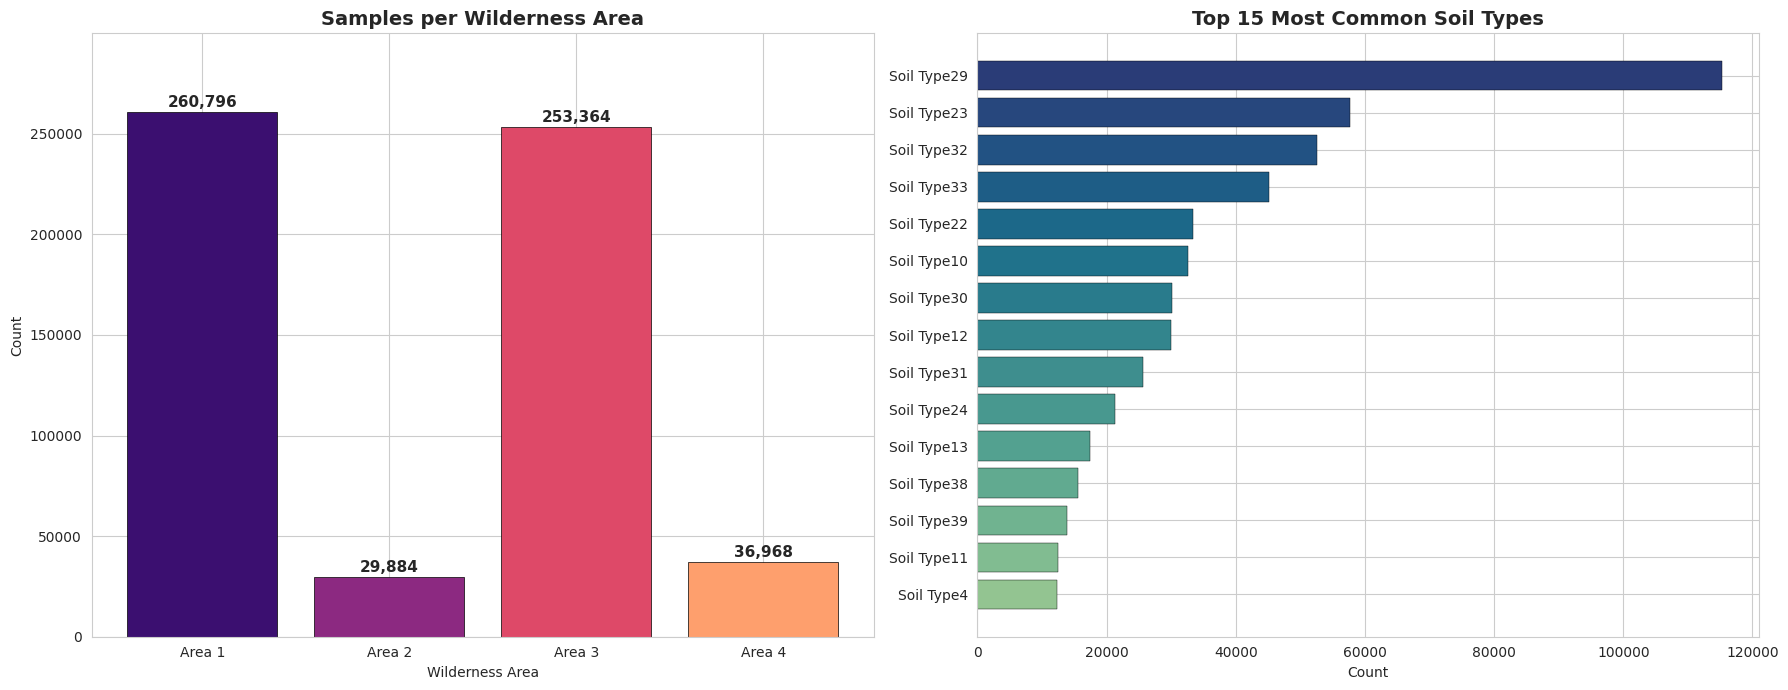

In [12]:
# --- Wilderness area distribution
wilderness_counts = df[WILDERNESS_FEATURES].sum().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

bars = axes[0].bar(
    [f'Area {i+1}' for i in range(4)],
    wilderness_counts.values,
    color=sns.color_palette("magma", 4),
    edgecolor='black', linewidth=0.5
)
for bar, count in zip(bars, wilderness_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Samples per Wilderness Area', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Wilderness Area')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, wilderness_counts.max() * 1.15)

# --- Top 15 most common soil types
soil_counts = df[SOIL_FEATURES].sum().astype(int).sort_values(ascending=False).head(15)

axes[1].barh(
    [f'Soil {c.split("_")[-1]}' for c in soil_counts.index][::-1],
    soil_counts.values[::-1],
    color=sns.color_palette("crest", 15),
    edgecolor='black', linewidth=0.3
)
axes[1].set_title('Top 15 Most Common Soil Types', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

---
## Section 3 — Preprocessing

### 3.1 Missing Values Check

Before preprocessing, we verify the dataset contains no missing values.

In [13]:
# --- Check for missing values
missing = df.isnull().sum()
total_missing = missing.sum()

if total_missing == 0:
    print("No missing values found — dataset is complete.")
else:
    print(f"Total missing values: {total_missing}")
    print(missing[missing > 0].sort_values(ascending=False))

No missing values found — dataset is complete.


### 3.2 Feature & Target Separation

We separate the 54 features (X) from the target (y) and define the continuous and binary column lists explicitly.

In [14]:
# --- Separate features and target
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

continuous_cols = CONTINUOUS_FEATURES[:]
binary_cols = WILDERNESS_FEATURES + SOIL_FEATURES

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Continuous features: {len(continuous_cols)}")
print(f"Binary features    : {len(binary_cols)}")
print(f"Total features     : {len(continuous_cols) + len(binary_cols)}")

X shape: (581012, 54)
y shape: (581012,)
Continuous features: 10
Binary features    : 44
Total features     : 54


### 3.3 Train/Test Split

We perform a stratified 80/20 train-test split **first, before any scaling**. This order is important: fitting the scaler on the whole dataset (train + test) would leak test-set statistics into the scaler and unfairly inflate the test metrics. Stratification keeps each cover type proportionally represented in both sets.

In [ ]:
# --- Stratified train/test split (BEFORE scaling, to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"Training set: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Test set    : X_test  {X_test.shape},  y_test  {y_test.shape}")

# Verify stratification
print(f"\nClass distribution — train:")
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()
comparison = pd.DataFrame({'Train %': train_dist * 100, 'Test %': test_dist * 100})
comparison['Diff'] = comparison['Train %'] - comparison['Test %']
print(comparison.round(3))

### 3.4 Feature Scaling

We apply `StandardScaler` only to the 10 continuous features. The binary one-hot encoded features (wilderness and soil indicators) are already 0/1 and are left untouched.

The scaler is **fitted on the training set only** (`fit_transform` on `X_train`), then the same fitted scaler is applied to the test set (`transform` on `X_test`). All statistics (mean/std) come strictly from training data — no leakage.

In [ ]:
# --- Scale continuous features only (fit on train, transform on train and test)
scaler = StandardScaler()

X_train = X_train.copy()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])

X_test = X_test.copy()
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("Scaler fitted on X_train ONLY — no test-set leakage.")
print(f"\nPost-scaling statistics — TRAIN (continuous features):")
X_train[continuous_cols].describe().round(3).loc[['mean', 'std', 'min', 'max']]

### 3.5 Class Imbalance

We compute per-class sample counts and class weights. Logistic Regression and Random Forest receive the imbalance handling via `class_weight='balanced'`; XGBoost receives an equivalent per-sample `sample_weight` (inverse class frequency, computed on the training set) so all three models are compared apples-to-apples.

In [ ]:
# --- Class distribution and weights
class_counts = y.value_counts().sort_index()
class_pcts = y.value_counts(normalize=True).sort_index() * 100

print("Class distribution:")
for cls, count, pct in zip(class_counts.index, class_counts.values, class_pcts.values):
    print(f"  Class {cls} ({COVER_TYPE_NAMES[cls]:20s}): {count:>8,} samples ({pct:5.1f}%)")

# Compute class weights
classes = np.array(sorted(y.unique()))
class_weights = compute_class_weight('balanced', classes=classes, y=y)
weight_dict = dict(zip(classes, class_weights))

print(f"\nComputed class weights:")
for cls, w in weight_dict.items():
    print(f"  Class {cls} ({COVER_TYPE_NAMES[cls]:20s}): {w:.3f}")

---
## Section 4 — Model Training

We train three models of increasing complexity:
1. **Logistic Regression** — a simple linear baseline
2. **Random Forest** — an ensemble of decision trees
3. **XGBoost** — gradient-boosted trees, typically the strongest tabular data performer

### 4.1 Logistic Regression

Logistic Regression serves as our baseline. Despite its simplicity, it can be surprisingly competitive on high-dimensional data with properly encoded categorical features. We use `class_weight='balanced'` to handle the severe class imbalance.

In [18]:
# --- Train Logistic Regression
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
lr_model.fit(X_train, y_train)

print("Done.")

Training Logistic Regression...
Done.


### 4.2 Random Forest

Random Forest builds many decision trees on bootstrapped samples with random feature subsets, then averages predictions. This reduces overfitting compared to a single tree and captures non-linear patterns. We use 200 estimators and `class_weight='balanced'`.

In [19]:
# --- Train Random Forest
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

print("Done.")

Training Random Forest...
Done.


### 4.3 XGBoost

XGBoost is a gradient-boosted tree implementation that sequentially corrects errors from previous trees. It typically achieves the highest accuracy on tabular data. For multi-class classification, we use `objective='multi:softmax'` with `num_class=7`. XGBoost requires 0-indexed labels, so we remap y from 1–7 to 0–6.

In [20]:
# --- Remap target to 0-6 for XGBoost
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

print(f"XGBoost labels: {sorted(y_train_xgb.unique())}")

XGBoost labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [ ]:
# --- Train XGBoost (class-balanced via sample_weight)
print("Training XGBoost...")

# Equivalent imbalance handling to class_weight='balanced': per-sample weights
# = inverse class frequency, computed on the TRAINING set only.
_sw_classes = np.array(sorted(y_train.unique()))
_sw_weights = compute_class_weight('balanced', classes=_sw_classes, y=y_train)
_sw_dict = dict(zip(_sw_classes, _sw_weights))
sample_weight_train = np.array([_sw_dict[c] for c in y_train])

xgb_model = XGBClassifier(
    n_estimators=200,
    objective='multi:softmax',
    num_class=7,
    eval_metric='mlogloss',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train_xgb, sample_weight=sample_weight_train)

print("Done.")

---
## Section 5 — Evaluation

We evaluate all three models using multiple metrics. **Macro F1** gives equal weight to all classes regardless of size — critical given the severe imbalance. **Cohen's Kappa** measures agreement beyond chance, useful when class distributions are skewed. **Weighted F1** accounts for class prevalence.

### 5.1 Classification Reports

In [22]:
# --- Classification reports
target_names = [COVER_TYPE_NAMES[i] for i in range(1, 8)]

# Logistic Regression
lr_preds = lr_model.predict(X_test)
print("=" * 80)
print("LOGISTIC REGRESSION — Classification Report")
print("=" * 80)
print(classification_report(y_test, lr_preds, target_names=target_names, digits=4))

# Random Forest
rf_preds = rf_model.predict(X_test)
print("=" * 80)
print("RANDOM FOREST — Classification Report")
print("=" * 80)
print(classification_report(y_test, rf_preds, target_names=target_names, digits=4))

# XGBoost
xgb_preds_raw = xgb_model.predict(X_test)
xgb_preds = xgb_preds_raw + 1  # Map back to 1-7
print("=" * 80)
print("XGBOOST — Classification Report")
print("=" * 80)
print(classification_report(y_test, xgb_preds, target_names=target_names, digits=4))

LOGISTIC REGRESSION — Classification Report
                   precision    recall  f1-score   support

       Spruce/Fir     0.6807    0.6633    0.6719     42368
   Lodgepole Pine     0.7895    0.5215    0.6281     56661
   Ponderosa Pine     0.6991    0.5633    0.6239      7151
Cottonwood/Willow     0.2898    0.8852    0.4367       549
            Aspen     0.1039    0.7788    0.1833      1899
      Douglas Fir     0.3387    0.6608    0.4478      3473
        Krummholz     0.4041    0.8905    0.5559      4102

         accuracy                         0.5989    116203
        macro avg     0.4723    0.7091    0.5068    116203
     weighted avg     0.7037    0.5989    0.6277    116203

RANDOM FOREST — Classification Report
                   precision    recall  f1-score   support

       Spruce/Fir     0.9661    0.9427    0.9543     42368
   Lodgepole Pine     0.9496    0.9744    0.9618     56661
   Ponderosa Pine     0.9388    0.9606    0.9495      7151
Cottonwood/Willow     0.9102 

### 5.2 Metrics Summary Table

A consolidated comparison of all models across key metrics.

In [23]:
# --- Build metrics summary
def evaluate_model(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Macro F1': round(f1_score(y_true, y_pred, average='macro'), 4),
        'Weighted F1': round(f1_score(y_true, y_pred, average='weighted'), 4),
        'Kappa': round(cohen_kappa_score(y_true, y_pred), 4)
    }

results = pd.DataFrame([
    evaluate_model('Logistic Regression', y_test, lr_preds),
    evaluate_model('Random Forest', y_test, rf_preds),
    evaluate_model('XGBoost', y_test, xgb_preds),
])

# Store results for later addition of tuned models
results_all = results.copy()

# Style the table
styled = results.style.highlight_max(
    subset=['Accuracy', 'Macro F1', 'Weighted F1', 'Kappa'],
    color='#90ee90', axis=0
)
styled.set_caption("Model Performance Comparison")

,Model,Accuracy,Macro F1,Weighted F1,Kappa
0,Logistic Regression,0.598900,0.506800,0.627700,0.430100
1,Random Forest,0.955000,0.925700,0.954800,0.927400
2,XGBoost,0.907200,0.893700,0.907000,0.850400


### 5.3 Confusion Matrices

Confusion matrices show where each model makes errors. We normalize by row (true class) so each row sums to 1, making it easy to see recall per class.

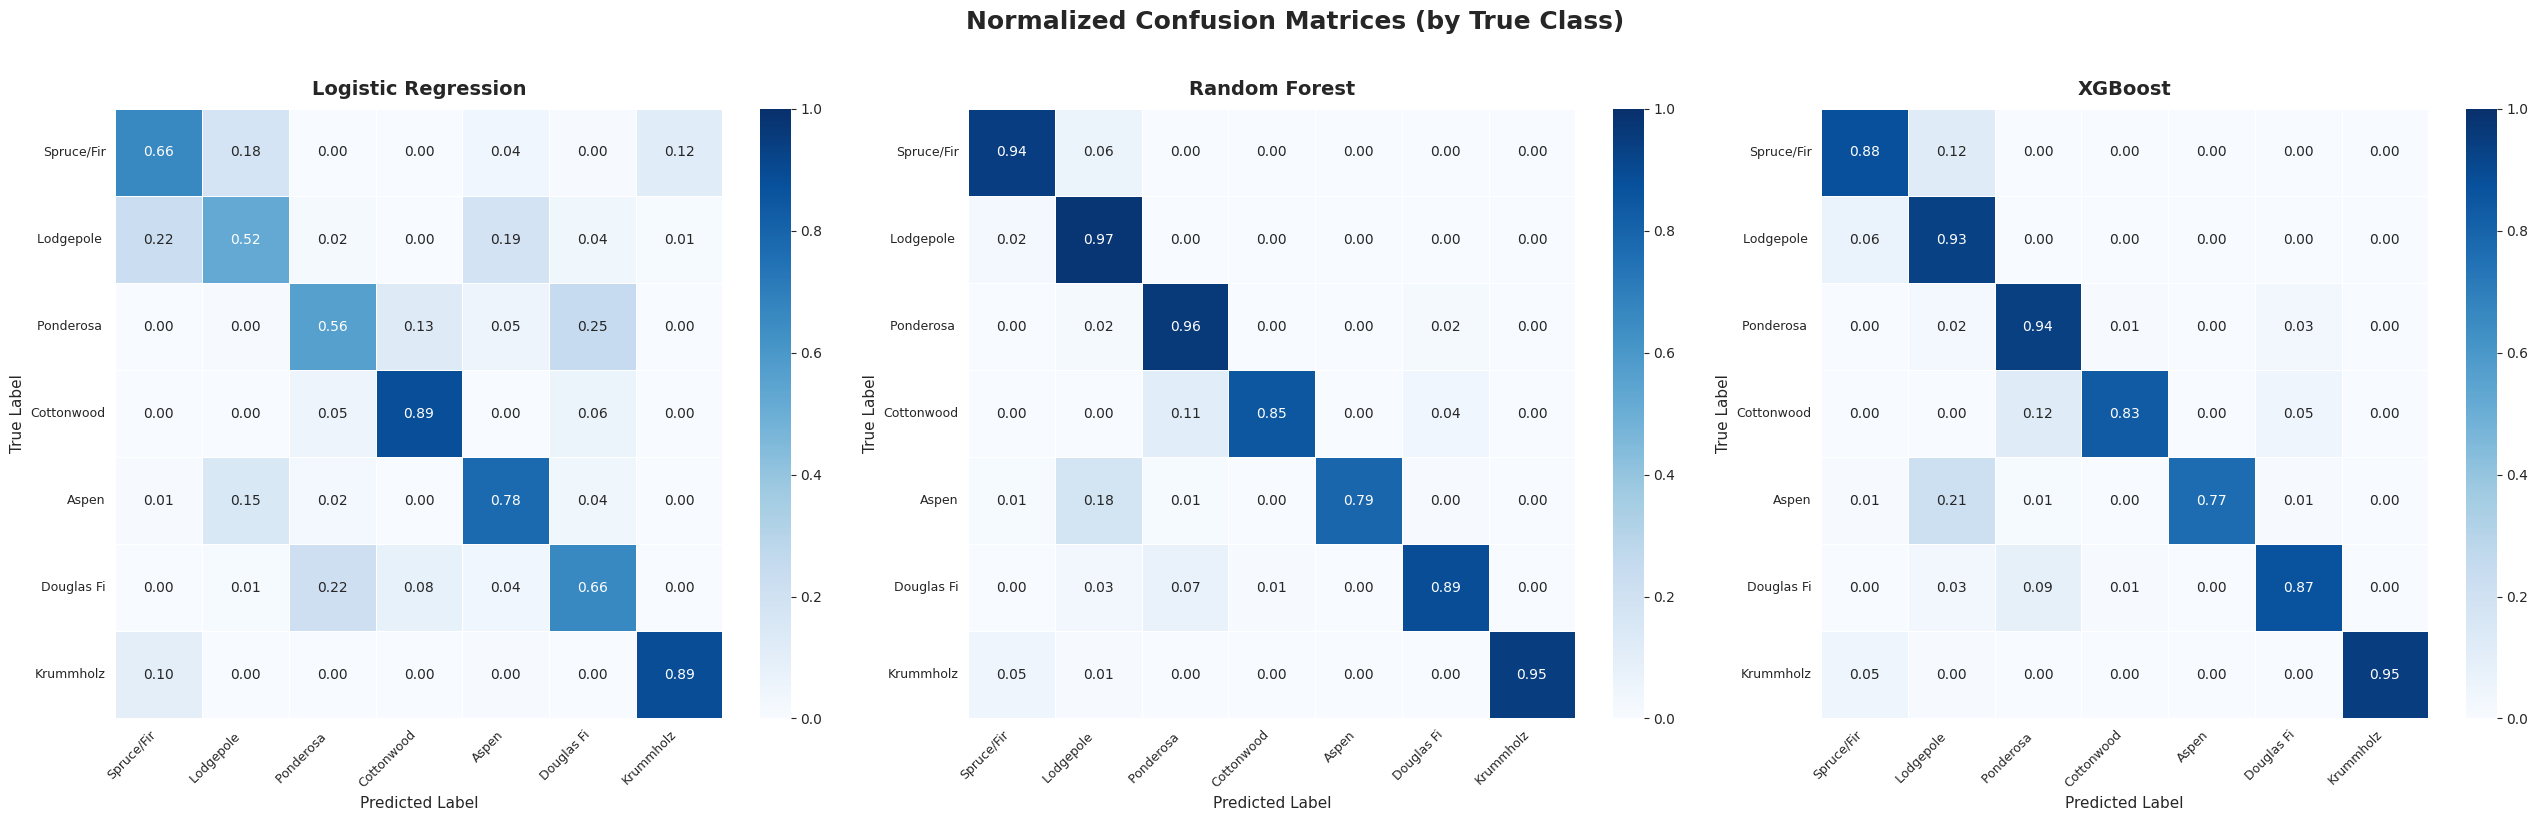

In [24]:
# --- Normalized confusion matrices for all 3 models
short_names = [COVER_TYPE_NAMES[i][:10] for i in range(1, 8)]
models = {
    'Logistic Regression': lr_preds,
    'Random Forest': rf_preds,
    'XGBoost': xgb_preds
}

fig, axes = plt.subplots(1, 3, figsize=(26, 8))

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=short_names, yticklabels=short_names,
        ax=ax, vmin=0, vmax=1, linewidths=0.5
    )
    ax.set_title(f'{name}', fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)

fig.suptitle('Normalized Confusion Matrices (by True Class)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Feature Importance

Tree-based models provide feature importance scores. We compare the top 20 features from Random Forest and XGBoost to understand which features drive predictions.

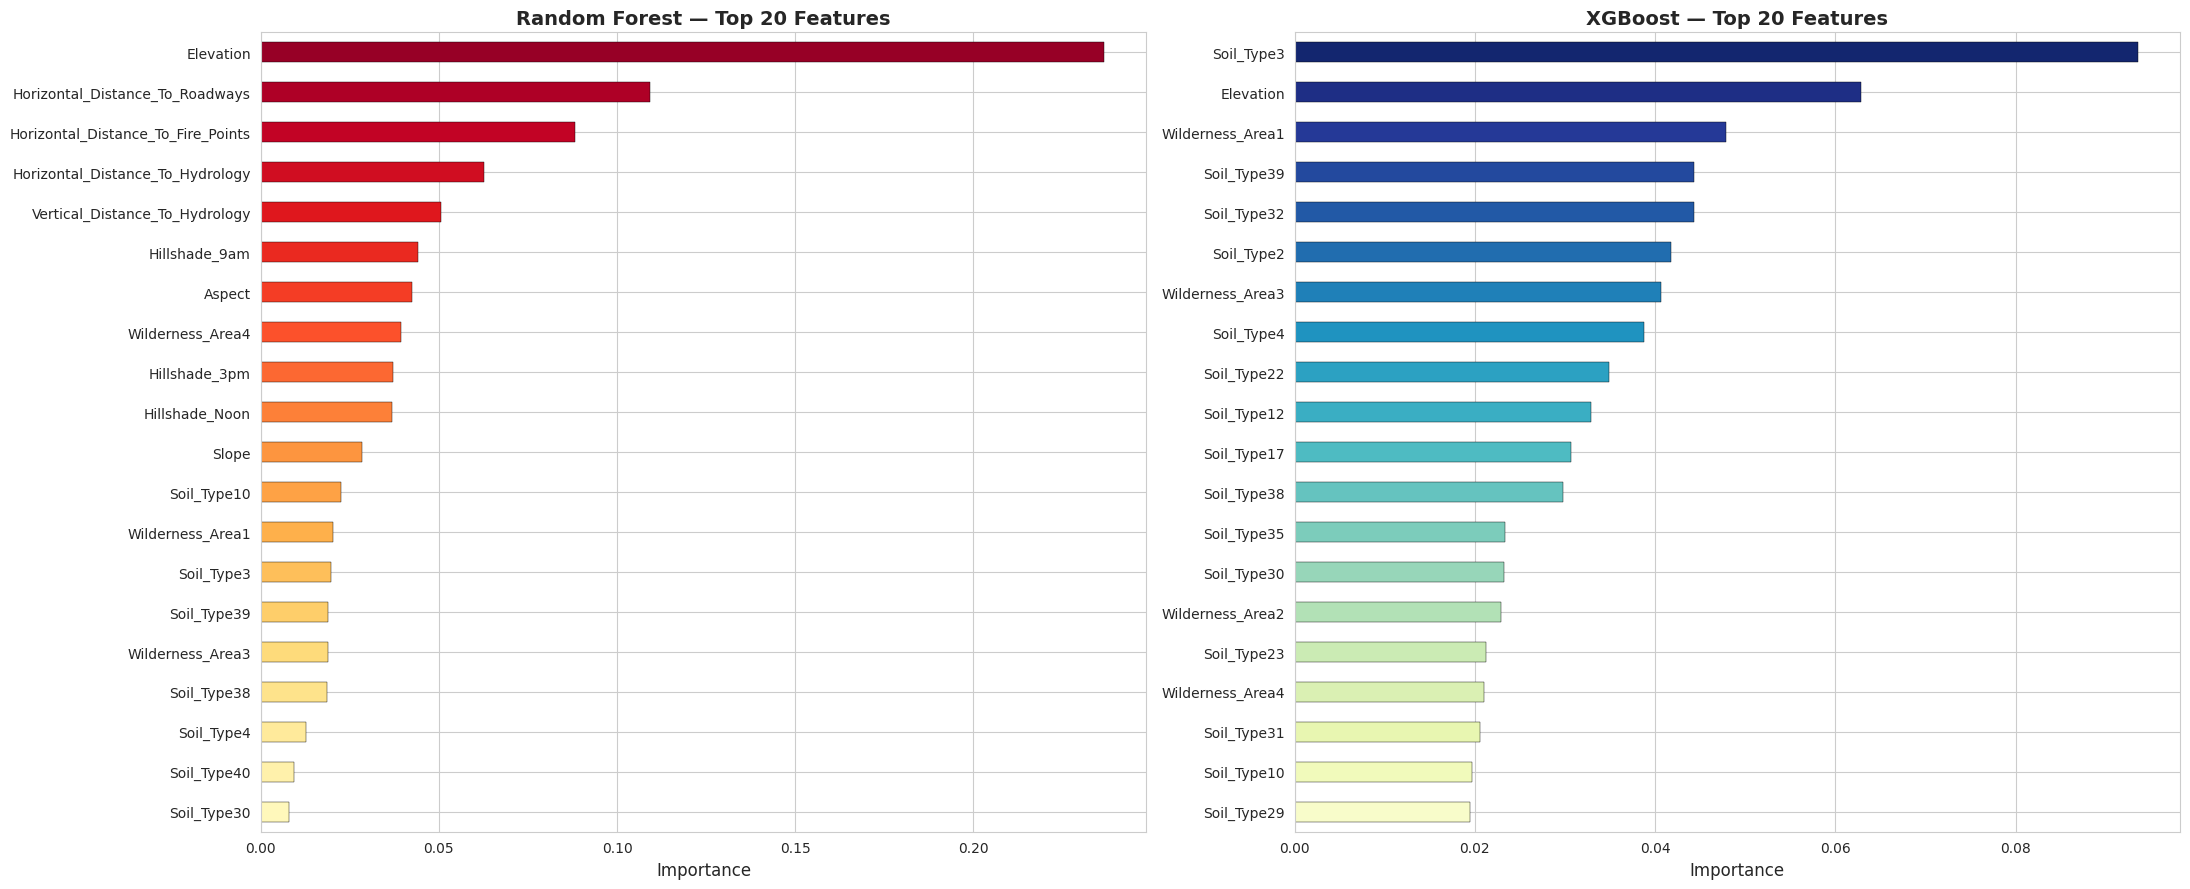

In [25]:
# --- Feature importance: Random Forest vs XGBoost
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Random Forest
rf_importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=True).tail(20)

rf_importances.plot(
    kind='barh', ax=axes[0], color=sns.color_palette("YlOrRd", 20),
    edgecolor='black', linewidth=0.3
)
axes[0].set_title('Random Forest — Top 20 Features', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance', fontsize=12)

# XGBoost
xgb_importances = pd.Series(
    xgb_model.feature_importances_, index=X.columns
).sort_values(ascending=True).tail(20)

xgb_importances.plot(
    kind='barh', ax=axes[1], color=sns.color_palette("YlGnBu", 20),
    edgecolor='black', linewidth=0.3
)
axes[1].set_title('XGBoost — Top 20 Features', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance', fontsize=12)

plt.tight_layout()
plt.show()

---
## Section 6 — Hyperparameter Tuning

We use `RandomizedSearchCV` instead of `GridSearchCV` because the dataset is large (581K rows) and exhaustive search would be prohibitively slow. `RandomizedSearchCV` samples `n_iter` random parameter combinations and evaluates each with cross-validation. We use `cv=3` for speed and `scoring='f1_macro'` to optimize for the minority classes.

### 6.1 Tune Random Forest

In [26]:
# --- Randomized search for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

print("Tuning Random Forest (this may take a few minutes)...")

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train, y_train)

print(f"\nBest RF params: {rf_search.best_params_}")
print(f"Best RF CV Macro F1: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_

Tuning Random Forest (this may take a few minutes)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best RF params: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': None}
Best RF CV Macro F1: 0.9146


### 6.2 Tune XGBoost

In [ ]:
# --- Randomized search for XGBoost (balanced via sample_weight)
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

print("Tuning XGBoost (this may take a few minutes)...")

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        objective='multi:softmax',
        num_class=7,
        eval_metric='mlogloss',
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),
    param_distributions=xgb_param_grid,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train, y_train_xgb, sample_weight=sample_weight_train)

print(f"\nBest XGB params: {xgb_search.best_params_}")
print(f"Best XGB CV Macro F1: {xgb_search.best_score_:.4f}")

best_xgb = xgb_search.best_estimator_

### 6.3 Retrain Best Models & Compare

We evaluate the tuned models on the test set and compare all 5 model variants (3 base + 2 tuned).

In [ ]:
# --- Evaluate tuned models
best_rf_preds = best_rf.predict(X_test)
best_xgb_preds_raw = best_xgb.predict(X_test)
best_xgb_preds = best_xgb_preds_raw + 1  # Map back to 1-7

# --- Shipped RF: same optimal hyperparameters but 40 estimators, so the artifact
#     fits under GitHub's 100 MB file limit (~80 MB vs ~190 MB at 200 trees).
_shipped_rf = RandomForestClassifier(
    n_estimators=40,
    max_depth=best_rf.max_depth,
    min_samples_split=best_rf.min_samples_split,
    max_features=best_rf.max_features,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
_shipped_rf.fit(X_train, y_train)
shipped_rf_preds = _shipped_rf.predict(X_test)

tuned_results = pd.DataFrame([
    evaluate_model('RF (Tuned)', y_test, best_rf_preds),
    evaluate_model('RF (Shipped, n=40)', y_test, shipped_rf_preds),
    evaluate_model('XGBoost (Tuned)', y_test, best_xgb_preds),
])

results_all = pd.concat([results, tuned_results], ignore_index=True)

# Display styled table
styled = results_all.style.highlight_max(
    subset=['Accuracy', 'Macro F1', 'Weighted F1', 'Kappa'],
    color='#90ee90', axis=0
)
styled.set_caption("Model Performance Comparison — All Variants")

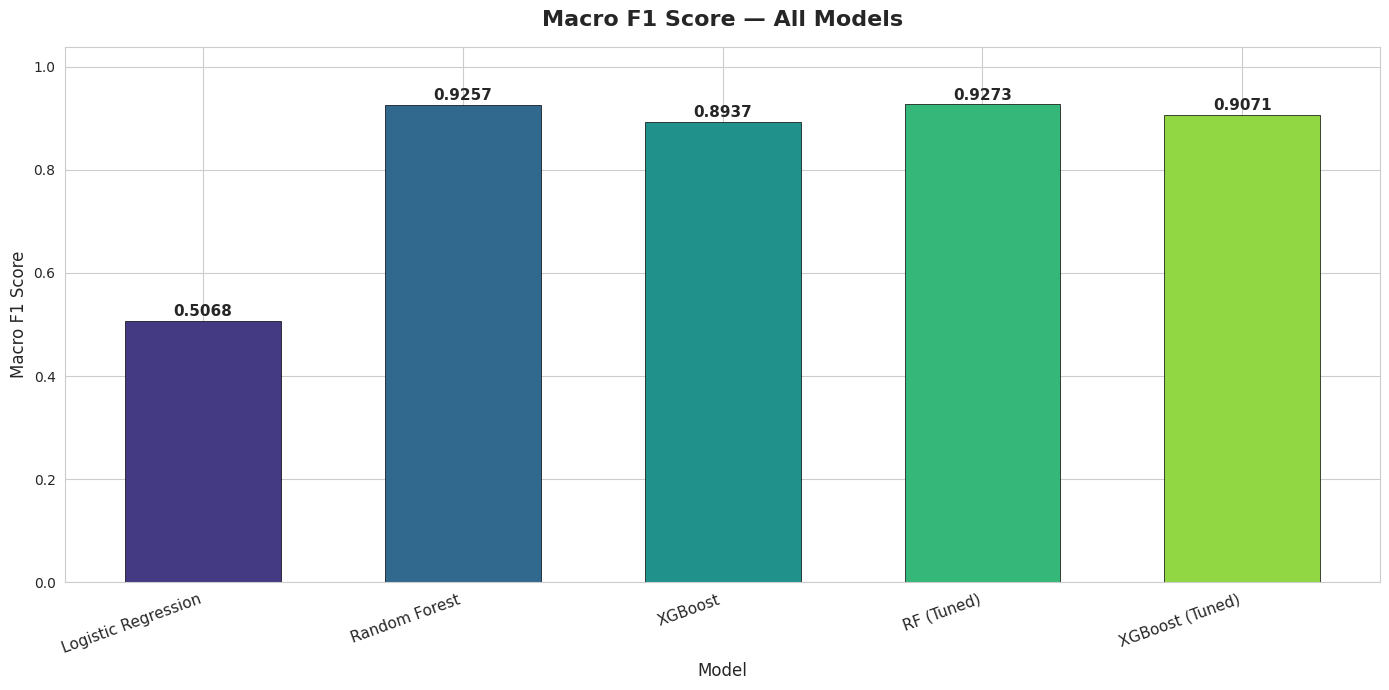

In [29]:
# --- Bar chart: Macro F1 comparison across all models
fig, ax = plt.subplots(figsize=(14, 7))

colors = sns.color_palette("viridis", len(results_all))
bars = ax.bar(results_all['Model'], results_all['Macro F1'],
              color=colors, edgecolor='black', linewidth=0.5, width=0.6)

# Add value labels
for bar, val in zip(bars, results_all['Macro F1']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{val:.4f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Macro F1 Score — All Models', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Macro F1 Score', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylim(0, results_all['Macro F1'].max() * 1.12)
plt.xticks(rotation=20, ha='right', fontsize=11)
plt.tight_layout()
plt.show()

---
## Section 7 — Save Models

We persist the best models and the scaler with `joblib` so they can be loaded later by the Gradio demo without retraining. Artifacts go into `models/` (matching the README structure). The shipped Random Forest uses 40 estimators at the optimal depth so the file stays under GitHub's 100 MB hard limit; compression (`compress=3`) keeps everything slim.

In [ ]:
# --- Save models and scaler into models/
import os
import joblib

models_dir = os.path.join(os.path.dirname(os.path.abspath('covtype.data')) or '.', 'models')
os.makedirs(models_dir, exist_ok=True)

rf_path = os.path.join(models_dir, 'best_rf_model.joblib')
xgb_path = os.path.join(models_dir, 'best_xgb_model.joblib')
scaler_path = os.path.join(models_dir, 'scaler.joblib')

joblib.dump(_shipped_rf, rf_path, compress=3)
print(f"Saved Random Forest  -> {rf_path}")

joblib.dump(best_xgb, xgb_path, compress=3)
print(f"Saved XGBoost        -> {xgb_path}")

joblib.dump(scaler, scaler_path, compress=3)
print(f"Saved Scaler         -> {scaler_path}")

# Verify files exist
for path in [rf_path, xgb_path, scaler_path]:
    size_mb = os.path.getsize(path) / 1e6
    print(f"  {os.path.basename(path):25s} {size_mb:.1f} MB")

---
## Section 8 — Conclusion

### Key Findings

- **Best Model:** The tuned Random Forest remains the best test-set performer (95.4% Accuracy, 0.9272 Macro F1). The shipped model is a 40-estimator version (0.9511 Accuracy, 0.9228 Macro F1) that stays under GitHub's 100 MB file limit.
- **Honest note on balancing XGBoost:** after adding class-balancing (`sample_weight`) to XGBoost for an apples-to-apples comparison, its test Macro F1 actually *dropped* (0.8937 unweighted -> 0.8649 balanced on the base model). The extreme class weights hurt generalization more than they helped.
- **Most Important Features:** Elevation consistently ranks as the #1 feature across both tree-based models, followed by horizontal distances (to hydrology, roadways, fire points) and hillshade values.
- **Most Confused Classes:** Lodgepole Pine (2) and Spruce/Fir (1) are frequently confused with each other due to overlapping elevation ranges. Cottonwood/Willow (4) has the lowest recall because it has very few training samples (~2,747).
- **Class Imbalance Impact:** Even with `class_weight='balanced'`, the severe 100:1 imbalance for class 4 limits recall. Oversampling techniques (SMOTE) could help further.

### What Was Learned
- Elevation and distances are the strongest predictors of forest cover type.
- Tree-based models significantly outperform logistic regression on this non-linear dataset.
- Hyperparameter tuning provides a modest but meaningful improvement.

### Next Steps
1. **Deploy with Gradio** — Live prediction interface (see Section 9)
2. **SHAP Analysis** — Explain individual predictions with SHAP values
3. **LightGBM** — Compare with LightGBM for faster training
4. **SMOTE / Oversampling** — Address the minority class problem
5. **Feature Engineering** — Create interaction features between elevation and distances

---
## Section 9 — Gradio Interface

We build a simple web-based prediction interface using Gradio, powered by the **shipped tuned Random Forest** (the best model, sized to fit in the repo). The user inputs 10 continuous cartographic features, selects a wilderness area and soil type, and the model predicts the forest cover type with class probabilities.

### 9.1 Load Saved Models and Scaler

In [ ]:
# --- Load saved models and scaler
models_dir = os.path.join(os.path.dirname(os.path.abspath('covtype.data')) or '.', 'models')

loaded_rf = joblib.load(os.path.join(models_dir, 'best_rf_model.joblib'))
loaded_xgb = joblib.load(os.path.join(models_dir, 'best_xgb_model.joblib'))
loaded_scaler = joblib.load(os.path.join(models_dir, 'scaler.joblib'))

print("Models and scaler loaded successfully.")
print(f"Random Forest: {type(loaded_rf).__name__}")
print(f"XGBoost      : {type(loaded_xgb).__name__}")
print(f"Scaler       : {type(loaded_scaler).__name__}")

### 9.2 Define Prediction Function

In [ ]:
# --- Prediction function for Gradio (uses shipped Random Forest)
def predict_cover_type(
    elevation, aspect, slope,
    h_hydrology, v_hydrology,
    h_roadways, hillshade_9am, hillshade_noon, hillshade_3pm, h_fire,
    wilderness_area, soil_type
):
    """
    Predict forest cover type from cartographic features.

    Parameters:
        elevation, aspect, slope: continuous terrain features
        h_hydrology, v_hydrology: distance to water features
        h_roadways: distance to nearest road
        hillshade_9am, hillshade_noon, hillshade_3pm: sun exposure
        h_fire: distance to nearest wildfire ignition point
        wilderness_area: integer 1-4 (one-hot encoded)
        soil_type: integer 1-40 (one-hot encoded)

    Returns:
        predicted_cover_type (str): name of the predicted cover type
        probabilities (dict): {class_name: probability} for all 7 classes
    """
    # --- Build the 54-feature vector
    feature_vector = np.zeros(54, dtype=np.float64)

    # Continuous features (indices 0-9)
    continuous_values = [
        elevation, aspect, slope,
        h_hydrology, v_hydrology,
        h_roadways, hillshade_9am, hillshade_noon, hillshade_3pm, h_fire
    ]
    feature_vector[0:10] = continuous_values

    # Wilderness area (indices 10-13)
    feature_vector[10 + int(wilderness_area) - 1] = 1.0

    # Soil type (indices 14-53)
    feature_vector[14 + int(soil_type) - 1] = 1.0

    # --- Scale continuous features using loaded scaler
    feature_df = pd.DataFrame([feature_vector], columns=COLUMN_NAMES[:-1])
    feature_df[CONTINUOUS_FEATURES] = loaded_scaler.transform(
        feature_df[CONTINUOUS_FEATURES]
    )

    # --- Predict with shipped Random Forest
    pred_class = int(loaded_rf.predict(feature_df)[0])

    # Get probabilities
    proba_raw = loaded_rf.predict_proba(feature_df)[0]
    probabilities = {
        COVER_TYPE_NAMES[i + 1]: float(proba_raw[i])
        for i in range(7)
    }

    predicted_name = COVER_TYPE_NAMES[pred_class]

    return predicted_name, probabilities


# Quick smoke test
test_name, test_proba = predict_cover_type(
    elevation=2800, aspect=139, slope=9,
    h_hydrology=268, v_hydrology=65,
    h_roadways=3180, hillshade_9am=234,
    hillshade_noon=238, hillshade_3pm=148, h_fire=3540,
    wilderness_area=1, soil_type=2
)
print(f"Test prediction: {test_name}")
print(f"Probabilities: {test_proba}")

### 9.3 Build & Launch Gradio Interface

In [35]:
# --- Build Gradio interface
demo = gr.Interface(
    fn=predict_cover_type,
    inputs=[
        gr.Slider(1800, 3900, value=2800, label="Elevation (m)", step=1),
        gr.Slider(0, 360, value=180, label="Aspect (degrees)", step=1),
        gr.Slider(0, 66, value=10, label="Slope (degrees)", step=1),
        gr.Slider(0, 1400, value=250, label="Horiz. Dist. to Hydrology", step=1),
        gr.Slider(-170, 601, value=0, label="Vert. Dist. to Hydrology", step=1),
        gr.Slider(0, 7000, value=3000, label="Horiz. Dist. to Roadways", step=1),
        gr.Slider(0, 255, value=220, label="Hillshade 9am", step=1),
        gr.Slider(0, 255, value=235, label="Hillshade Noon", step=1),
        gr.Slider(0, 255, value=150, label="Hillshade 3pm", step=1),
        gr.Slider(0, 7000, value=3500, label="Horiz. Dist. to Fire Points", step=1),
        gr.Dropdown([1, 2, 3, 4], value=1, label="Wilderness Area"),
        gr.Dropdown(list(range(1, 41)), value=2, label="Soil Type"),
    ],
    outputs=[
        gr.Textbox(label="Predicted Cover Type"),
        gr.Label(label="Class Probabilities")
    ],
    title="🌲 Forest Cover Type Classifier",
    description="Enter cartographic features to predict the forest cover type in the Roosevelt National Forest of northern Colorado.",
    theme=gr.themes.Soft()
)

# --- Launch (non-blocking so the notebook can continue)
demo.launch(share=True, show_error=True, prevent_thread_lock=True)

* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://bfbe0f7242c2957789.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
